# Unpaired Multimodal Learning -- Colab Pipeline

**CS 5330 Pattern Recognition and Computer Vision -- Final Project**

Arul Agarwal, Anirudh Bakare, Utkarsh Milind Khursale

---

This notebook orchestrates the full project pipeline on a Google Colab GPU runtime: repository setup, data ingestion, hyperparameter tuning, model training, and latent-space evaluation.

## 1. Setup and Clone

Clone the project repository from GitHub and install all Python dependencies listed in `requirements.txt`.

In [ ]:
!git clone https://github.com/arulagarwal/CS5330-Final_Project.git
%cd CS5330-Final_Project


In [5]:
# Navigate to the project folder
%cd /content/drive/MyDrive/FinalProject



/content/drive/MyDrive/FinalProject


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install -r requirements.txt

## 2. Kaggle Authentication

Securely prompt for Kaggle API credentials and write them to a local `.env` file. This avoids hardcoding secrets in the notebook. You can obtain your API token from [kaggle.com/settings](https://www.kaggle.com/settings).

In [7]:
import getpass

kaggle_username = getpass.getpass(prompt="Kaggle Username: ")
kaggle_key = getpass.getpass(prompt="Kaggle API Key: ")

with open(".env", "w") as f:
    f.write(f"KAGGLE_USERNAME={kaggle_username}\n")
    f.write(f"KAGGLE_KEY={kaggle_key}\n")

print("Credentials written to .env")

Kaggle Username: ··········
Kaggle API Key: ··········
Credentials written to .env


### Load Environment Variables

Read the `.env` file created above and inject the Kaggle credentials into the current process environment so that `kagglehub` can authenticate.

In [8]:
from dotenv import load_dotenv
import os

load_dotenv()

assert os.environ.get("KAGGLE_USERNAME"), "KAGGLE_USERNAME not set"
assert os.environ.get("KAGGLE_KEY"), "KAGGLE_KEY not set"
print("Environment variables loaded successfully.")

Environment variables loaded successfully.


## 3. Data Ingestion

Download the Stanford Cars dataset and generate synthetic unpaired text descriptions. This creates `data/images/` (196 class subfolders) and `data/text/` (196 CSV files with 5 descriptions each).

In [9]:
!python download_data.py

INFO: Data directories ready: ./data/images, ./data/text
INFO: Downloading pre-organized dataset: jutrera/stanford-car-dataset-by-classes-folder
Using Colab cache for faster access to the 'stanford-car-dataset-by-classes-folder' dataset.
INFO: Downloaded to /kaggle/input/stanford-car-dataset-by-classes-folder
INFO: Found 392 class directories in pre-built dataset
INFO: Generated 196 text CSV files in ./data/text

Done! Summary:
  Classes:      196
  Images:       16139
  Text files:   196


In [10]:
# Generate the Zero-Shot Text Anchors from the dataset
!python init_weights.py

02:09:15 INFO: Device: cuda
02:09:16 INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
02:09:16 WARNING: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
02:09:16 INFO: HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
config.json: 100% 483/483 [00:00<00:00, 2.38MB/s]
02:09:16 INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
02:09:16 INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
02:09:16 INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"
02:09:16 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/xet-read-token/12040a

## 4. Targeted Hyperparameter Tuning

Run a lightweight grid search over Learning Rate (`[1e-4, 5e-5]`) and Projection Dimension (`[256, 512]`). Each combination trains for up to 5 epochs with early stopping (patience of 2). The best parameters are saved to `best_params.txt`.

In [11]:
!python tune.py

02:09:57 INFO: Device: cuda
02:09:57 INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
02:09:57 WARNING: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
02:09:57 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
02:09:57 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
02:09:57 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
02:09:57 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expand=fal

## 5. Final Model Training

Train the Unpaired Multimodal Learner for 20 epochs. The command below uses baseline parameters as a starting point. After reviewing the tuning results from Cell 4 (printed to console and saved in `best_params.txt`), substitute the `--lr` flag with the best learning rate identified by the grid search. The best model checkpoint is saved to `checkpoints/best_model.pt`, and the final top-1 test accuracy is reported at the end.

In [12]:
python train.py --epochs 20 --batch-size 32 --lr 1e-4

02:37:26 INFO: Using device: cuda
02:37:26 INFO: Splits — train: 11297 | val: 2420 | test: 2422
02:37:26 INFO: Loading pretrained weights from Hugging Face hub (timm/vit_small_patch16_224.augreg_in21k_ft_in1k)
02:37:27 INFO: HTTP Request: HEAD https://huggingface.co/timm/vit_small_patch16_224.augreg_in21k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
02:37:27 INFO: [timm/vit_small_patch16_224.augreg_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
02:37:27 INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
02:37:27 WARNING: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
02:37:27 INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
02:37:27 INFO: HTTP Request: HEAD https://huggingfac

## 6. Latent Space Evaluation

Load the frozen best checkpoint and extract 512-d shared-backbone embeddings for 5 selected car classes across both modalities. Reduce to 2-D with t-SNE and save the scatter plot to `latent_space.png`. Clustering of image and text points from the same class provides evidence of learned cross-modal synergies.

In [13]:
!python test.py

03:04:40 INFO: Using device: cuda
03:04:41 INFO: HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
03:04:41 WARNING: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
03:04:41 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
03:04:41 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
03:04:41 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
03:04:41 INFO: HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expa

---

### Display Latent Space Plot

Render the saved scatter plot inline for review.

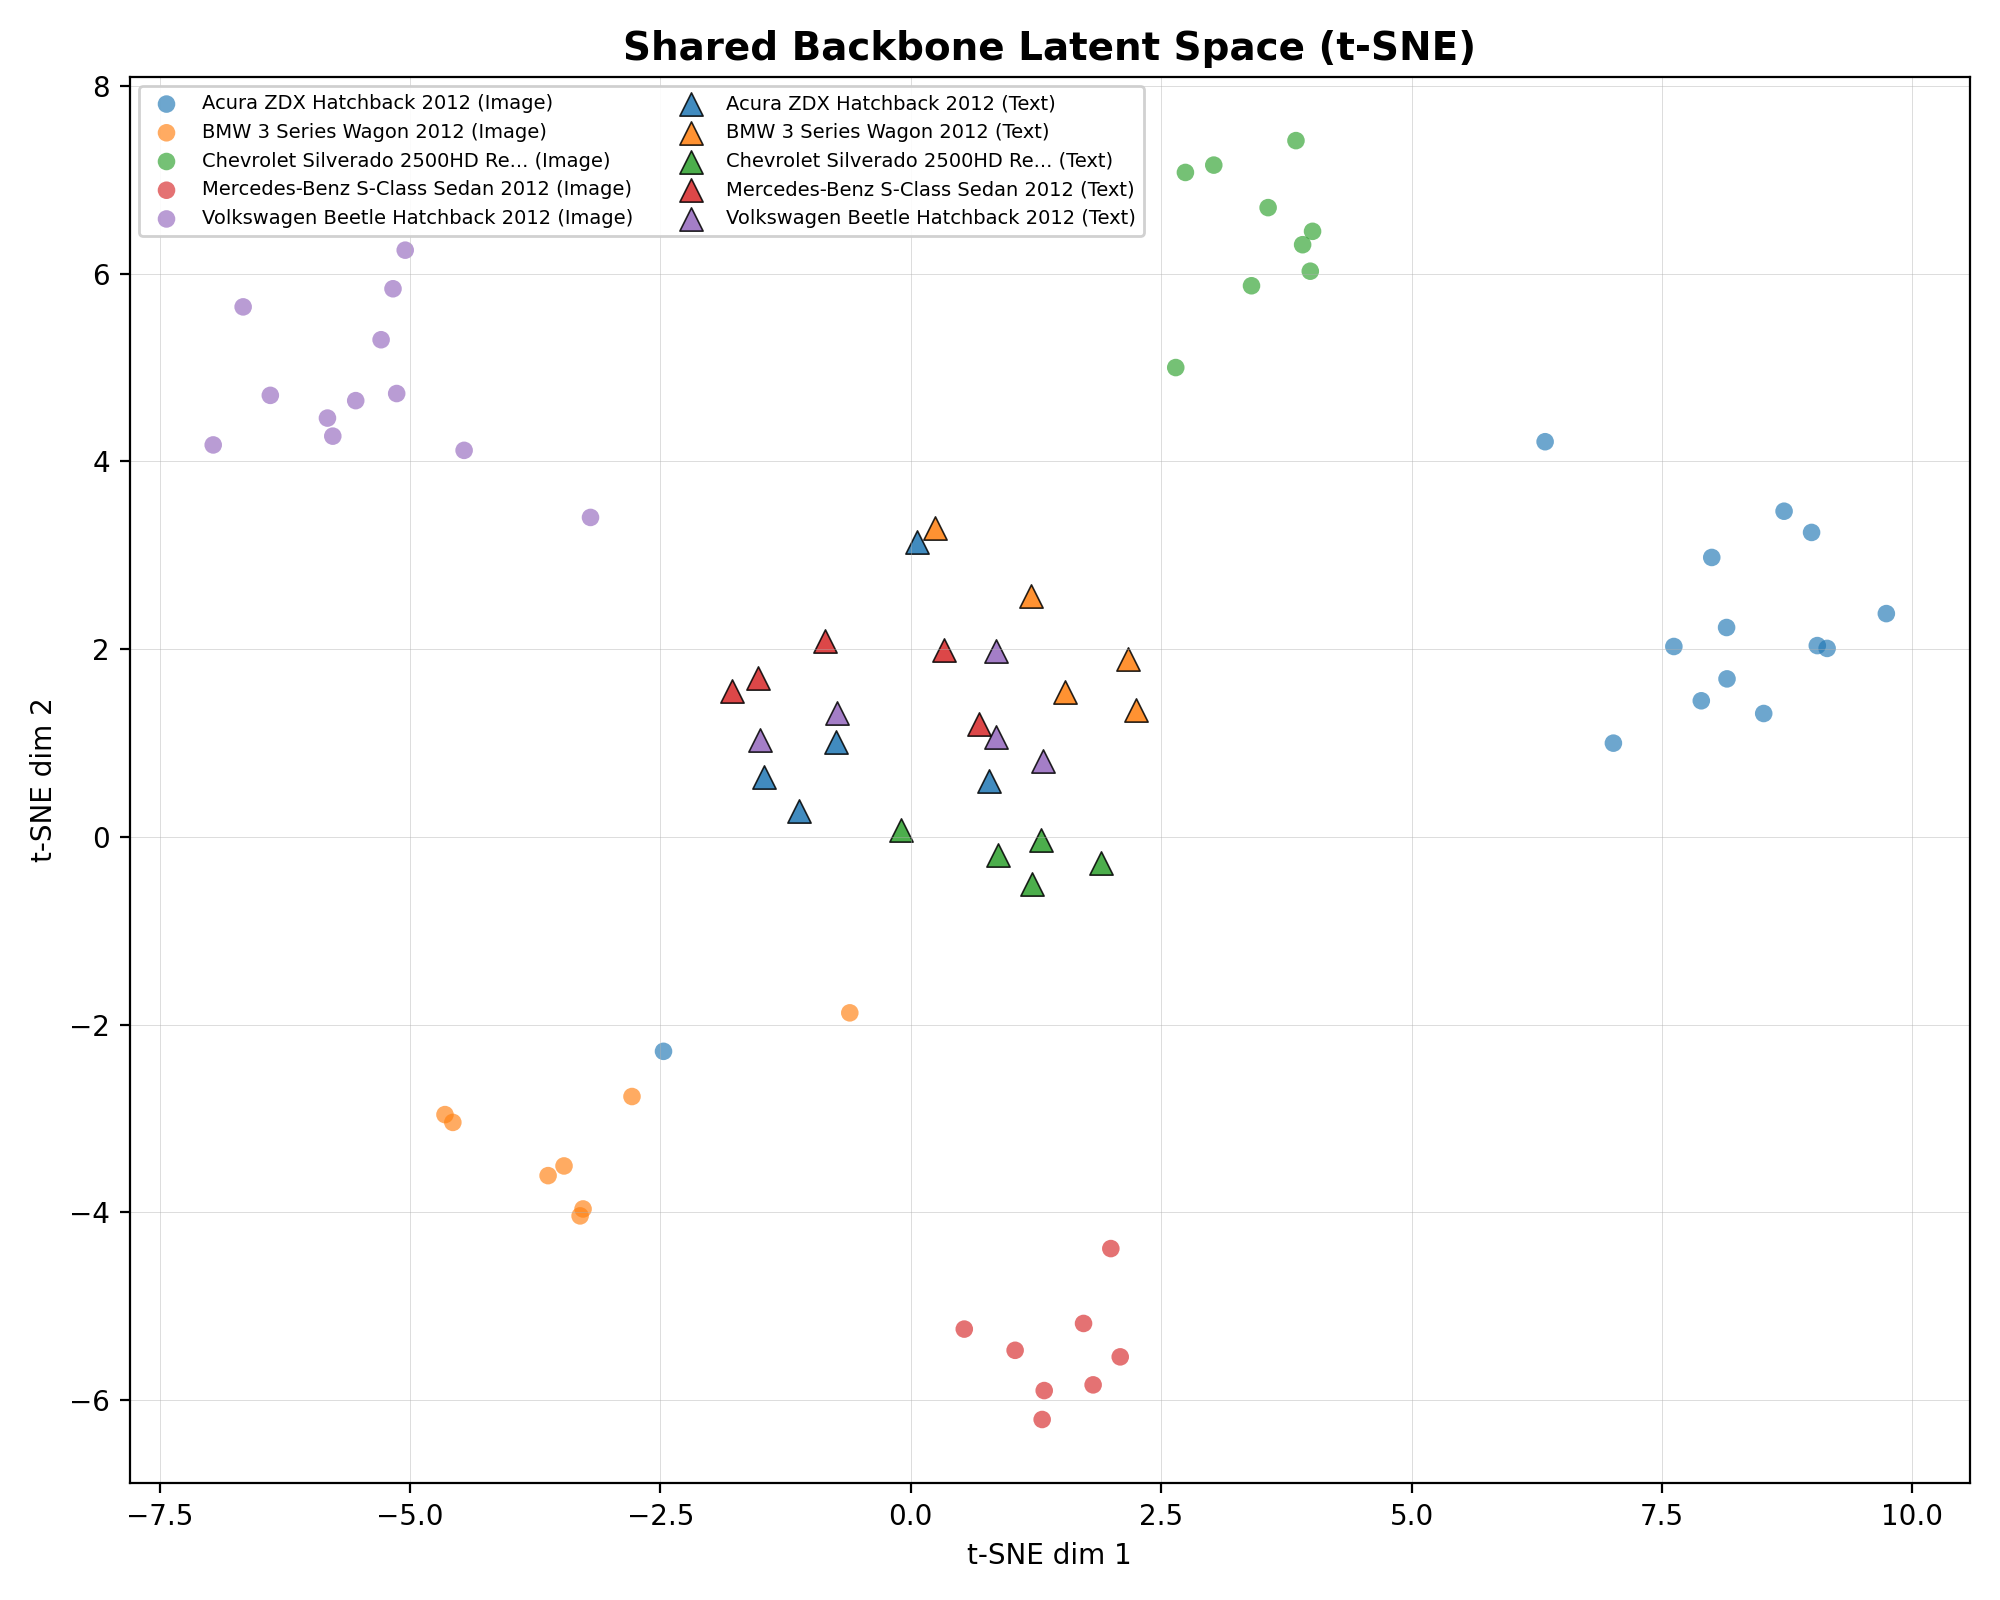

In [14]:
from IPython.display import Image, display
display(Image(filename="latent_space.png"))